# Employee Attrition Prediction



In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### read CSV

In [166]:
df = pd.read_csv('hr-employee-attrition-with-null.csv')

### Dataset statistic

In [167]:
df.describe()

,Unnamed: 0,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1176.000000,1176.000000,1176.00000,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,...,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,734.500000,37.134354,798.875850,9.37500,2.920918,1.0,1031.399660,2.733844,65.821429,2.728741,...,2.694728,80.0,0.752551,11.295068,2.787415,2.770408,7.067177,4.290816,2.159014,4.096939
std,424.496761,9.190317,406.957684,8.23049,1.028796,0.0,601.188955,1.092992,20.317323,0.705280,...,1.093660,0.0,0.822550,7.783376,1.290507,0.705004,6.127836,3.630901,3.163524,3.537393
min,0.000000,18.000000,102.000000,1.00000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,367.250000,30.000000,457.750000,2.00000,2.000000,1.0,494.750000,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,734.500000,36.000000,798.500000,7.00000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1101.750000,43.000000,1168.250000,15.00000,4.000000,1.0,1562.250000,4.000000,84.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,2.250000,7.000000
max,1469.000000,60.000000,1499.000000,29.00000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


In [168]:
df.head()

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41.0,Yes,Travel_Rarely,NaN,NaN,1.0,NaN,Life Sciences,1.0,...,1.0,80.0,0.0,8.0,0.0,NaN,6.0,NaN,0.0,NaN
1,1,NaN,No,NaN,279.0,Research & Development,NaN,NaN,Life Sciences,1.0,...,4.0,NaN,1.0,10.0,NaN,3.0,10.0,NaN,NaN,7.0
2,2,37.0,Yes,NaN,1373.0,NaN,2.0,2.0,NaN,1.0,...,NaN,80.0,0.0,7.0,3.0,NaN,NaN,0.0,NaN,0.0
3,3,NaN,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,NaN,...,3.0,NaN,NaN,8.0,3.0,NaN,8.0,NaN,3.0,0.0
4,4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,...,4.0,80.0,1.0,6.0,NaN,3.0,2.0,2.0,2.0,NaN


### Feature transformation

In [169]:
df.loc[df["Attrition"] == "no", "Attrition"] = 0.0
df.loc[df["Attrition"] == "yes", "Attrition"] = 1.0
string_categorical_col = ['Department', 'Attrition', 'BusinessTravel', 'EducationField', 'Gender', 'JobRole',
                              'MaritalStatus', 'Over18', 'OverTime']

# ENCODE STRING COLUMNS TO CATEGORICAL COLUMNS
for col in string_categorical_col:
    df[col] = pd.Categorical(df[col]).codes

# HANDLE NULL NUMBERS
# Fill null numeric values with the median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

df = df.loc[:, ~df.columns.isin(['EmployeeNumber', 'Unnamed: 0', 'EmployeeCount', 'StandardHours', 'Over18'])]

/var/folders/rh/z58c3kq54dn9qwl5gdsxhb_00000gn/T/ipykernel_59007/570767050.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


###  Spliting data into train and test

In [170]:
from sklearn.model_selection import train_test_split

In [171]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Attrition'])

### Display histogram of each feature

In [172]:
def display_histogram(df, col_name, cls, n_bin = 40):
    # Filter data by class
    data_class_0 = df[df['Attrition'] == 0][col_name].dropna()
    data_class_1 = df[df['Attrition'] == 1][col_name].dropna()
    
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(data_class_0, bins=n_bin, alpha=0.5, label='No Attrition (0)', color='blue', edgecolor='black')
    plt.hist(data_class_1, bins=n_bin, alpha=0.5, label='Attrition (1)', color='red', edgecolor='black')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col_name} with {n_bin} bins')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### T4. Observe the histogram for Age, MonthlyIncome and DistanceFromHome. How many bins have zero counts? Do you think this is a good discretization? Why?

**T4 Answer:** With 40 bins, many bins have zero counts, especially for discrete features or features with sparse distributions. This is not ideal discretization because:
1. Zero counts lead to zero probability estimates which can cause numerical issues
2. Too many bins for continuous data can lead to overfitting
3. Bins with zero counts don't contribute useful information for classification

### T5. Can we use a Gaussian to estimate this histogram? Why? What about a Gaussian Mixture Model (GMM)?

**T5 Answer:** 
- **Single Gaussian:** Not appropriate for most of these features because the distributions are often multimodal, skewed, or have irregular shapes that cannot be captured by a single bell curve.
- **Gaussian Mixture Model (GMM):** Yes, GMM can be used as it can model complex distributions by combining multiple Gaussians. This allows it to capture multimodal distributions and more complex patterns in the data.

### T6. Now plot the histogram according to the method described above (with 10, 40, and 100 bins) and show 3 plots each for Age, MonthlyIncome, and DistanceFromHome. Which bin size is most sensible for each features? Why?

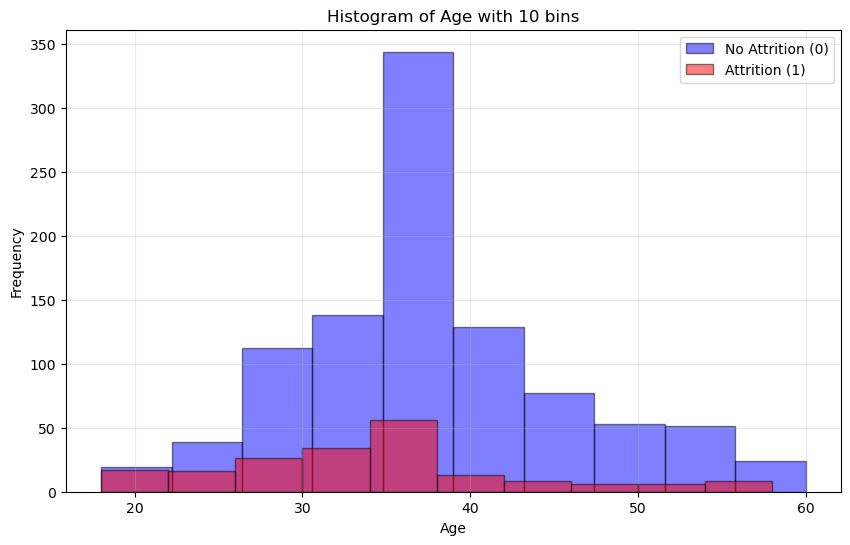

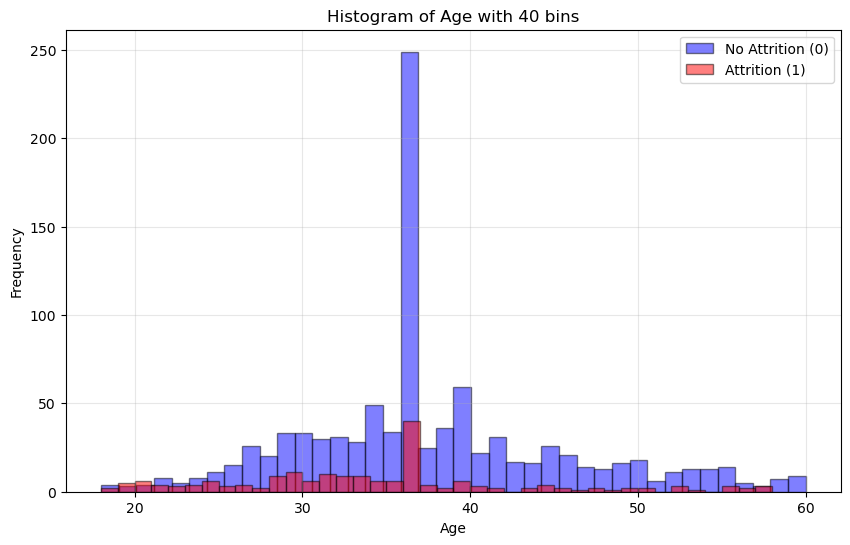

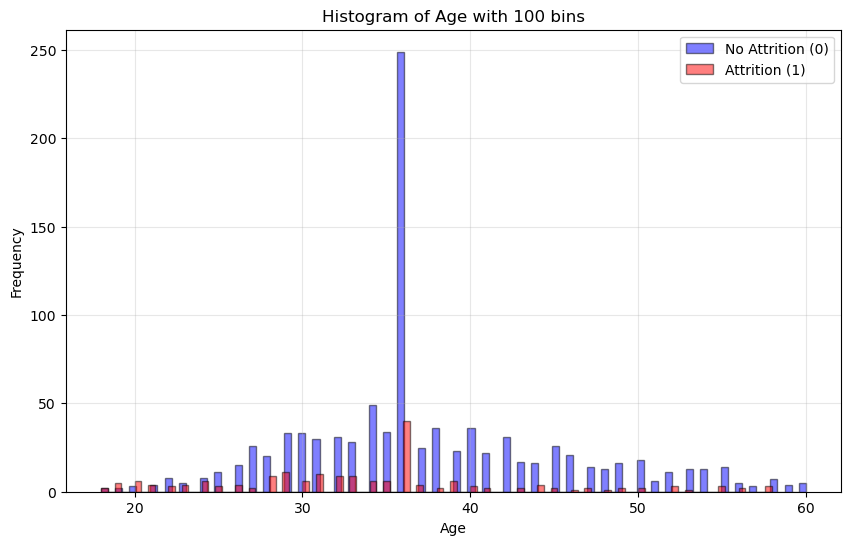

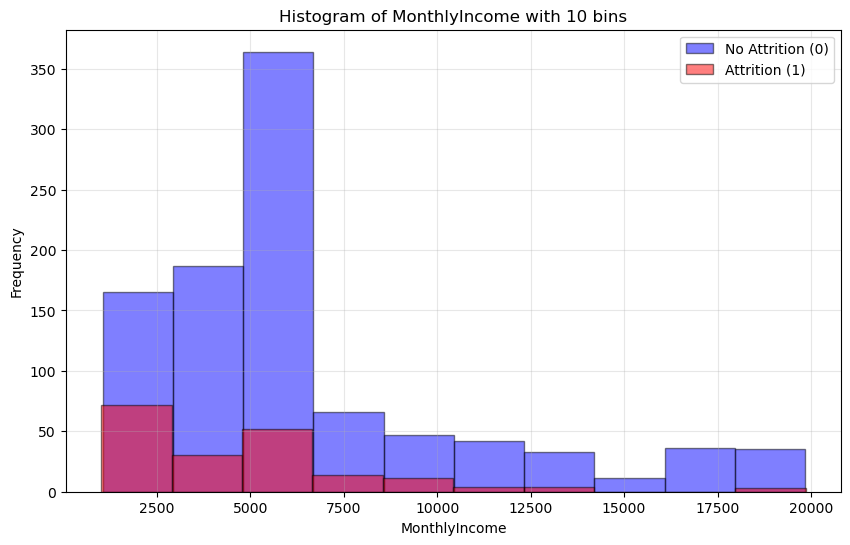

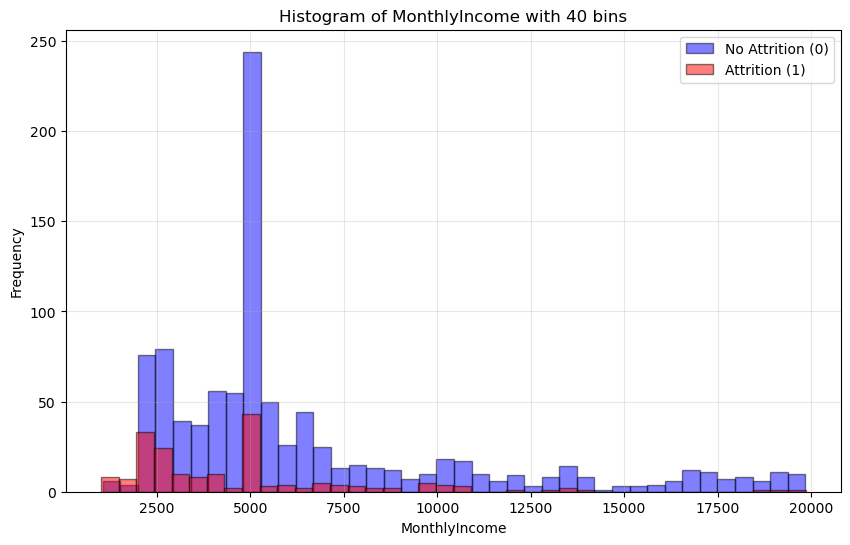

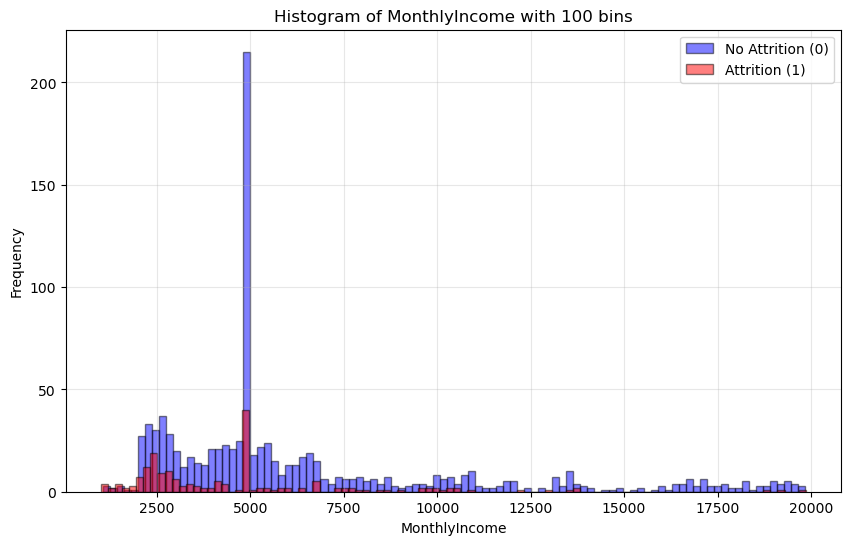

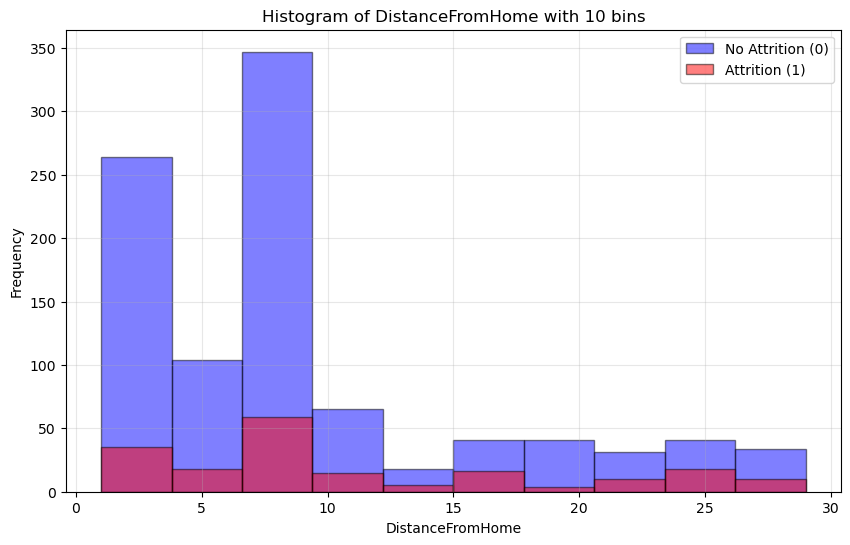

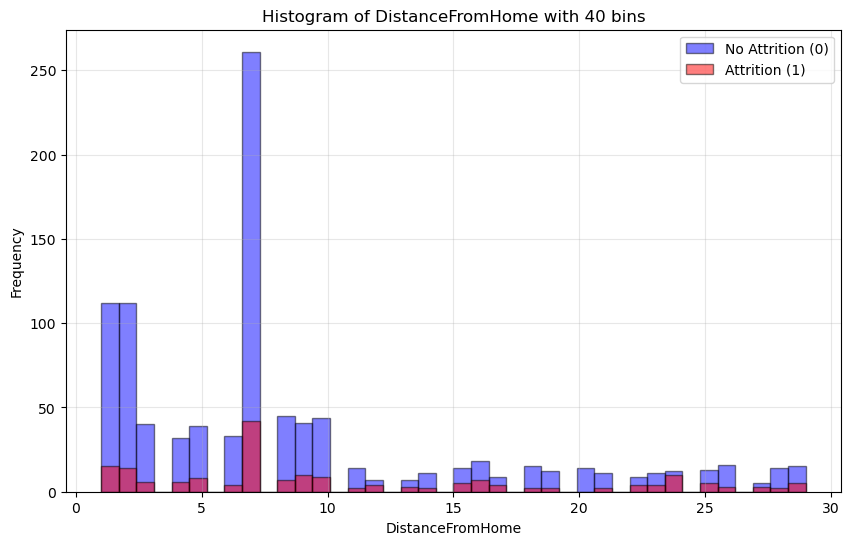

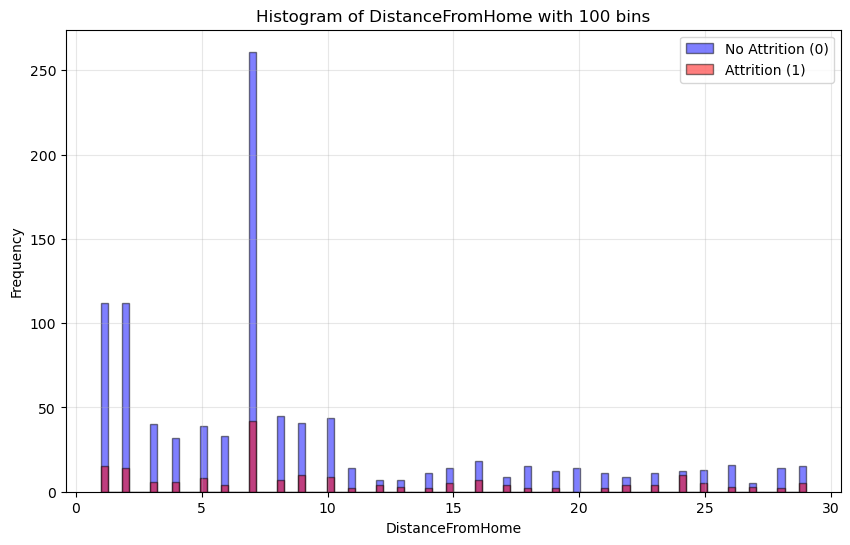

In [173]:
# T6: Plot histograms with different bin sizes
features_to_plot = ['Age', 'MonthlyIncome', 'DistanceFromHome']
bin_sizes = [10, 40, 100]

for feature in features_to_plot:
    if feature in df_train.columns:
        for n_bins in bin_sizes:
            display_histogram(df_train, feature, 'Attrition', n_bin=n_bins)

**T6 Answer:** 
- **Age:** 10-40 bins is most sensible. Age has a reasonable range (~18-60) and a moderate number of bins captures the distribution without creating too many empty bins.
- **MonthlyIncome:** 10-40 bins is appropriate. Income varies widely but too many bins create sparsity.
- **DistanceFromHome:** 10 bins is sufficient. This feature has a smaller range and fewer distinct values, so fewer bins prevent overfitting.

The key is balancing between capturing the distribution shape and avoiding sparse bins with zero counts.

### T7. For the rest of the features, which one should be discretized in order to be modeled by histograms? What are the criteria for choosing whether we should discretize a feature or not? Answer this and discretize those features into 10 bins each. In other words, figure out the bin edge for each feature, then use digitize() to convert the features to discrete values

**T7 Answer:** 

**Features that should be discretized:**
- Continuous features with many distinct values should be discretized (e.g., Age, MonthlyIncome, DistanceFromHome, HourlyRate, DailyRate, MonthlyRate, etc.)

**Criteria for discretization:**
1. The feature has many distinct continuous or integer values
2. The feature is not already categorical
3. Discretization can help capture non-linear relationships
4. The number of distinct values is large relative to sample size

**Features that should NOT be discretized:**
- Already categorical features (e.g., JobRole, Department, MaritalStatus)
- Binary features (e.g., Gender, OverTime)
- Features with very few distinct values already

### T8. What kind of distribution should we use to model histograms? (Answer a distribution name) What is the MLE for the likelihood distribution? (Describe how to do the MLE). Plot the likelihood distributions of MonthlyIncome, JobRole, HourlyRate, and MaritalStatus for different Attrition values.

**T8 Answer:**

**Distribution type:** Categorical/Multinomial distribution (or Discrete distribution)

**MLE for likelihood distribution:**
For each bin i and class c, the MLE is:
$$P(x_i | c) = \frac{count(x_i, c)}{N_c}$$

where:
- $count(x_i, c)$ is the number of samples in bin i for class c
- $N_c$ is the total number of samples in class c

To avoid zero probabilities, we use Laplace smoothing (add-one smoothing):
$$P(x_i | c) = \frac{count(x_i, c) + 1}{N_c + K}$$

where K is the number of bins.

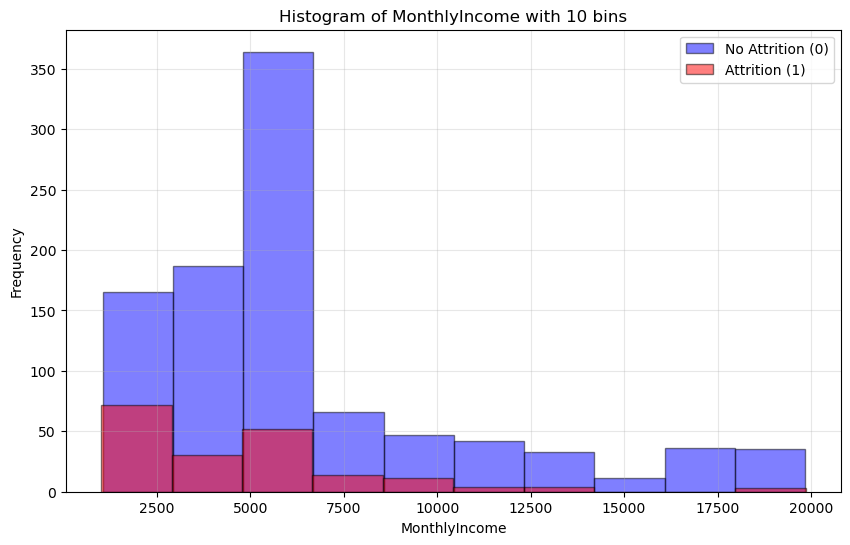

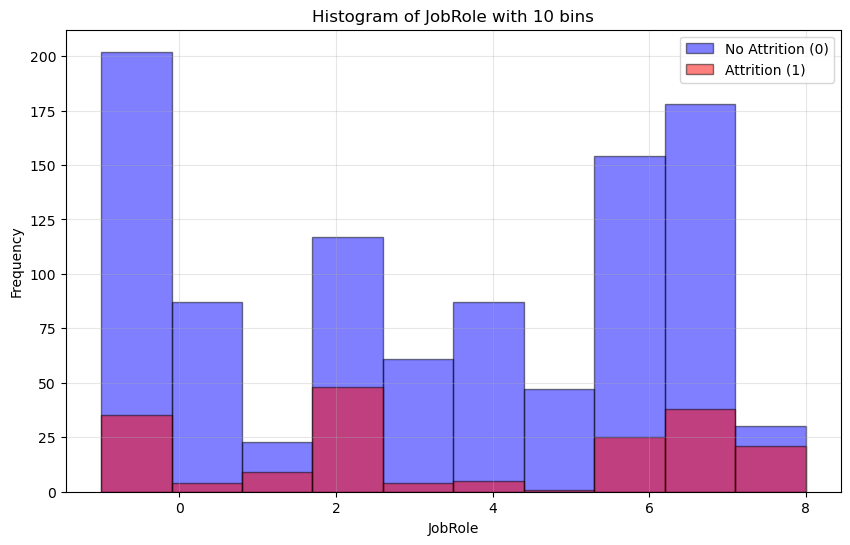

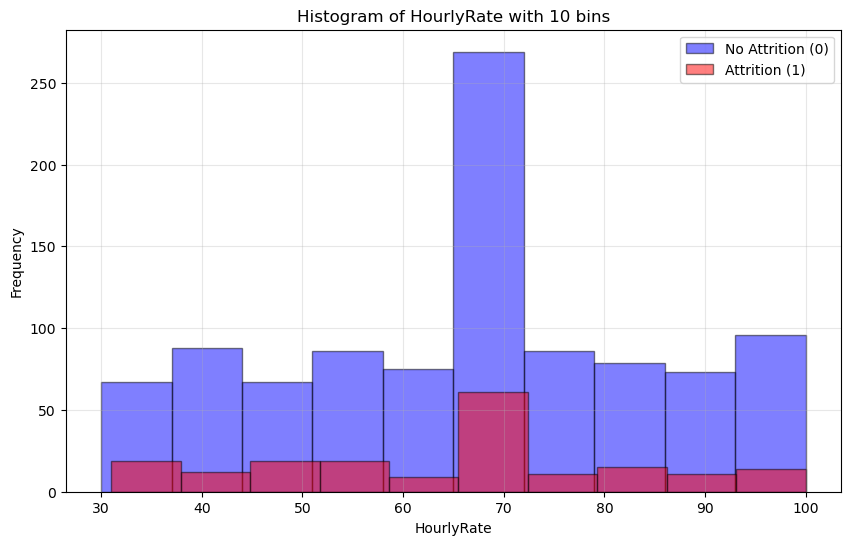

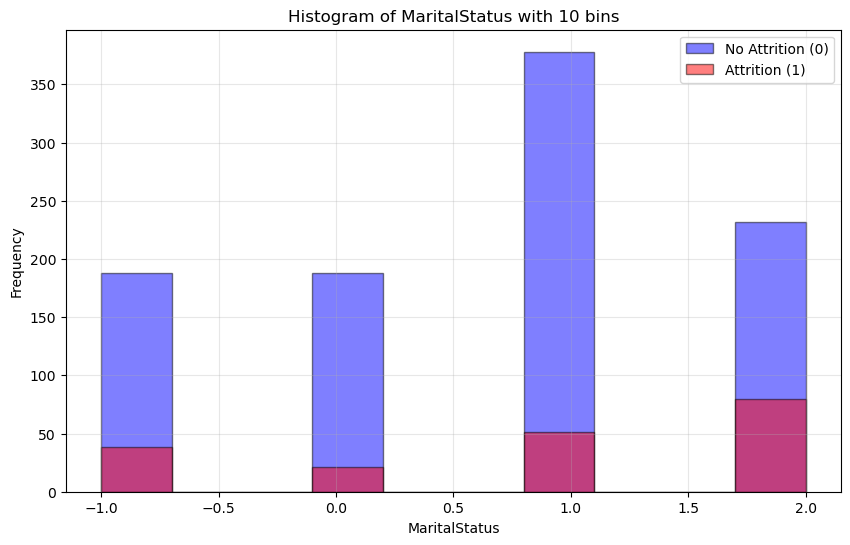

In [174]:
# T8: Plot likelihood distributions
features_to_plot_t8 = ['MonthlyIncome', 'JobRole', 'HourlyRate', 'MaritalStatus']

for feature in features_to_plot_t8:
    if feature in df_train.columns:
        display_histogram(df_train, feature, 'Attrition', n_bin=10)

### T9. What is the prior distribution of the two classes?

In [175]:
# T9: Calculate prior distribution
n_total = len(y_train)
n_attrition = np.sum(y_train == 1)
n_no_attrition = np.sum(y_train == 0)

prior_attrition = n_attrition / n_total
prior_no_attrition = n_no_attrition / n_total

print(f"Prior P(Attrition=1) = {prior_attrition:.4f}")
print(f"Prior P(Attrition=0) = {prior_no_attrition:.4f}")

Prior P(Attrition=1) = 0.0366
Prior P(Attrition=0) = 0.1412


### T10. If we use the current Naive Bayes with our current Maximum Likelihood Estimates, we will find that some P (x i |attrition) will be zero and will result in the entire product term to be zero. Propose a method to fix this problem.

**T10 Answer:**

**Solution: Laplace Smoothing (Add-one smoothing)**

When a feature value appears in the test set but never appeared with a particular class in the training set, the probability P(x_i | class) = 0, making the entire product zero.

**Fix:** Add a small constant (typically 1) to all counts:
$$P(x_i | c) = \frac{count(x_i, c) + \alpha}{N_c + \alpha \times K}$$

where:
- $\alpha$ is the smoothing parameter (usually 1)
- $K$ is the number of possible values/bins
- This ensures no probability is exactly zero

This method is implemented in the SimpleBayesClassifier by adding 1 to all bin counts during the fit_params method.

### T11. Implement your Naive Bayes classifier. Use the learned distributions to classify the test set. Don’t forget to allow your classifier to handle missing values in the test set. Report the overall Accuracy. Then, report the Precision, Recall, and F score for detecting attrition. See Lecture 1 for the definitions of each metric.


In [176]:
from SimpleBayesClassifier import SimpleBayesClassifier

In [177]:
data_train = df_train.to_numpy()
data_test = df_test.to_numpy()

In [178]:
x_train = data_train[:, :-1]  # All columns except last (Attrition)
y_train = data_train[:, -1]   # Last column (Attrition)

x_test = data_test[:, :-1]
y_test = data_test[:, -1]

In [179]:
model = SimpleBayesClassifier(n_pos=int(np.sum(y_train == 1)), n_neg=int(np.sum(y_train == 0)))

In [180]:
def check_prior():
    """
    This function designed to test the implementation of the prior probability calculation in a Naive Bayes classifier. 
    Specifically, it checks if the classifier correctly computes the prior probabilities for the 
    negative and positive classes based on given input counts.
    """
    
    # prior_neg = 5/(5 + 5) = 0.5 and # prior_pos = 5/(5 + 5) = 0.5
    assert (SimpleBayesClassifier(5, 5).prior_pos, SimpleBayesClassifier(5, 5).prior_neg) == (0.5, 0.5)

    assert (SimpleBayesClassifier(3, 5).prior_pos, SimpleBayesClassifier(3, 5).prior_neg) == (3/8, 5/8)
    assert (SimpleBayesClassifier(0, 1).prior_pos, SimpleBayesClassifier(0, 1).prior_neg) == (0.0, 1.0)
    assert (SimpleBayesClassifier(1, 0).prior_pos, SimpleBayesClassifier(1, 0).prior_neg) == (1.0, 0.0)
    
check_prior()

In [181]:
model.fit_params(x_train, y_train)

([(array([17, 11, 21, 19, 58, 23, 10,  9,  3,  5]),
   array([18. , 22.2, 26.4, 30.6, 34.8, 39. , 43.2, 47.4, 51.6, 55.8, 60. ])),
  (array([108,   1,   1,   1,   1,   1,   1,   1,   1,  60]),
   array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])),
  (array([29,  1,  1, 16,  1,  1, 29,  1,  1, 96]),
   array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8,  1.1,  1.4,  1.7,  2. ])),
  (array([19, 13, 20, 19, 44, 12, 10, 15, 13, 11]),
   array([ 104. ,  243.1,  382.2,  521.3,  660.4,  799.5,  938.6, 1077.7,
          1216.8, 1355.9, 1495. ])),
  (array([42,  1,  1,  9,  1,  1, 79,  1,  1, 40]),
   array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8,  1.1,  1.4,  1.7,  2. ])),
  (array([47, 16, 52, 13,  5,  9,  6,  9, 12,  7]),
   array([ 1. ,  3.8,  6.6,  9.4, 12.2, 15. , 17.8, 20.6, 23.4, 26.2, 29. ])),
  (array([19,  1, 26,  1, 92,  1,  1, 27,  1,  7]),
   array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ])),
  (array([37,  4,  1, 54, 21,  1, 39,  1,  6, 12]),
   array([-

In [182]:
def check_fit_params():

    """
    This function is designed to test the fit_params method of a SimpleBayesClassifier. 
    This method is presumably responsible for computing parameters for a Naive Bayes classifier 
    based on the provided training data. The parameters in this context is bins and edges from each histogram.
    """

    T = SimpleBayesClassifier(2, 2)
    X_TRAIN_CASE_1 = np.array([
        [0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5],
        [3, 4, 5, 6]
    ])
    Y_TRAIN_CASE_1 = np.array([0, 1, 0, 1])
    STAY_PARAMS_1, LEAVE_PARAMS_1 = T.fit_params(X_TRAIN_CASE_1, Y_TRAIN_CASE_1)

    print("STAY PARAMETERS")
    for f_idx in range(len(STAY_PARAMS_1)):
        print(f"Feature : {f_idx}")
        print(f"BINS : {STAY_PARAMS_1[f_idx][0]}")
        print(f"EDGES : {STAY_PARAMS_1[f_idx][1]}")
    print("")    
    print("LEAVE PARAMETERS")
    for f_idx in range(len(STAY_PARAMS_1)):
        print(f"Feature : {f_idx}")
        print(f"BINS : {LEAVE_PARAMS_1[f_idx][0]}")
        print(f"EDGES : {LEAVE_PARAMS_1[f_idx][1]}")

check_fit_params()

STAY PARAMETERS
Feature : 0
BINS : [2 1 1 1 1 1 2 1 1 1]
EDGES : [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
Feature : 1
BINS : [2 1 1 1 1 1 2 1 1 1]
EDGES : [1.  1.3 1.6 1.9 2.2 2.5 2.8 3.1 3.4 3.7 4. ]
Feature : 2
BINS : [2 1 1 1 1 1 2 1 1 1]
EDGES : [2.  2.3 2.6 2.9 3.2 3.5 3.8 4.1 4.4 4.7 5. ]
Feature : 3
BINS : [2 1 1 1 1 1 2 1 1 1]
EDGES : [3.  3.3 3.6 3.9 4.2 4.5 4.8 5.1 5.4 5.7 6. ]

LEAVE PARAMETERS
Feature : 0
BINS : [1 1 1 2 1 1 1 1 1 2]
EDGES : [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
Feature : 1
BINS : [1 1 1 2 1 1 1 1 1 2]
EDGES : [1.  1.3 1.6 1.9 2.2 2.5 2.8 3.1 3.4 3.7 4. ]
Feature : 2
BINS : [1 1 1 2 1 1 1 1 1 2]
EDGES : [2.  2.3 2.6 2.9 3.2 3.5 3.8 4.1 4.4 4.7 5. ]
Feature : 3
BINS : [1 1 1 2 1 1 1 1 1 2]
EDGES : [3.  3.3 3.6 3.9 4.2 4.5 4.8 5.1 5.4 5.7 6. ]


In [183]:
y_pred = model.predict(x = x_test)

In [184]:
def evaluate(y_true, y_pred, show_result = True):
    # Calculate metrics
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    if show_result:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {F1:.4f}")
        print(f"FPR: {fpr:.4f}")
    
    return accuracy, precision, recall, F1, fpr

In [185]:
evaluate(y_test, y_pred)

Accuracy: 0.8226
Precision: 0.7500
Recall: 0.2308
F1 Score: 0.3529
FPR: 0.0204


(0.8225806451612904,
 0.75,
 0.23076923076923078,
 0.3529411764705882,
 0.02040816326530612)

### T12. Use the learned distributions to classify the test set. Report the results using the same metric as the previous question.


In [186]:
model.fit_gaussian_params(x_train, y_train)

([(35.204819277108435, 8.695323540464916),
  (0.35542168674698793, 0.4786409001923194),
  (1.144578313253012, 1.1473650286318104),
  (745.855421686747, 366.32734004025247),
  (0.6927710843373494, 1.084755608757175),
  (9.373493975903614, 7.907920146608996),
  (2.86144578313253, 0.9307765025305168),
  (1.4819277108433735, 1.738032718251885),
  (2.746987951807229, 1.0160563201112296),
  (0.3132530120481928, 0.7750275680036333),
  (66.355421686747, 17.815322719989133),
  (2.716867469879518, 0.6928758433103265),
  (1.8253012048192772, 0.9876762765946878),
  (3.13855421686747, 3.2615072029680294),
  (2.9096385542168677, 0.9237318833127457),
  (0.7771084337349398, 1.077572606918849),
  (4979.183734939759, 4030.2182260611157),
  (14095.277108433735, 5900.313825252343),
  (2.8012048192771086, 2.2607704186316457),
  (0.060240963855421686, 0.6465738730119874),
  (15.331325301204819, 3.5658834458799706),
  (3.1686746987951806, 0.3744643438053025),
  (2.789156626506024, 0.9366065443085648),
  (0.7

In [187]:
def check_fit_gaussian_params():

    """
    This function is designed to test the fit_gaussian_params method of a SimpleBayesClassifier. 
    This method is presumably responsible for computing parameters for a Naive Bayes classifier 
    based on the provided training data. The parameters in this context is mean and STD.
    """

    T = SimpleBayesClassifier(2, 2)
    X_TRAIN_CASE_1 = np.array([
        [0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5],
        [3, 4, 5, 6]
    ])
    Y_TRAIN_CASE_1 = np.array([0, 1, 0, 1])
    STAY_PARAMS_1, LEAVE_PARAMS_1 = T.fit_gaussian_params(X_TRAIN_CASE_1, Y_TRAIN_CASE_1)

    print("STAY PARAMETERS")
    for f_idx in range(len(STAY_PARAMS_1)):
        print(f"Feature : {f_idx}")
        print(f"Mean : {STAY_PARAMS_1[f_idx][0]}")
        print(f"STD. : {STAY_PARAMS_1[f_idx][1]}")
    print("")    
    print("LEAVE PARAMETERS")
    for f_idx in range(len(STAY_PARAMS_1)):
        print(f"Feature : {f_idx}")
        print(f"Mean : {LEAVE_PARAMS_1[f_idx][0]}")
        print(f"STD. : {LEAVE_PARAMS_1[f_idx][1]}")
    
check_fit_gaussian_params()

STAY PARAMETERS
Feature : 0
Mean : 1.0
STD. : 1.0
Feature : 1
Mean : 2.0
STD. : 1.0
Feature : 2
Mean : 3.0
STD. : 1.0
Feature : 3
Mean : 4.0
STD. : 1.0

LEAVE PARAMETERS
Feature : 0
Mean : 2.0
STD. : 1.0
Feature : 1
Mean : 3.0
STD. : 1.0
Feature : 2
Mean : 4.0
STD. : 1.0
Feature : 3
Mean : 5.0
STD. : 1.0


In [188]:
y_pred = model.gaussian_predict(x_test)

In [189]:
evaluate(y_test, y_pred)

Accuracy: 0.7581
Precision: 0.3750
Recall: 0.2308
F1 Score: 0.2857
FPR: 0.1020


(0.7580645161290323,
 0.375,
 0.23076923076923078,
 0.2857142857142857,
 0.10204081632653061)

### T13 : The random choice baseline is the accuracy if you make a random guess for each test sample. Give random guess (50% leaving, and 50% staying) to the test samples. Report the overall Accuracy. Then, report the Precision, Recall, and F score for attrition prediction using the random choice baseline.

In [190]:
# T13: Random choice baseline
np.random.seed(42)
y_pred_random = np.random.choice([0, 1], size=len(y_test), p=[0.5, 0.5])
print("Random Choice Baseline:")
evaluate(y_test, y_pred_random)

Random Choice Baseline:
Accuracy: 0.3871
Precision: 0.1212
Recall: 0.3077
F1 Score: 0.1739
FPR: 0.5918


(0.3870967741935484,
 0.12121212121212122,
 0.3076923076923077,
 0.17391304347826086,
 0.5918367346938775)

### T14. The majority rule is the accuracy if you use the most frequent class from the training set as the classification decision. Report the overall Accuracy. Then, report the Precision, Recall, and F score for attrition prediction using the majority rule baseline.



In [191]:
# T14: Majority rule baseline
# The most frequent class in training set
majority_class = int(np.round(np.mean(y_train)))
y_pred_majority = np.full(len(y_test), majority_class)
print("Majority Rule Baseline:")
evaluate(y_test, y_pred_majority)

Majority Rule Baseline:
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
FPR: 0.0000


(0, 0, 0, 0, 0)

### T15. Compare the two baselines with your Naive Bayes classifier.


**T15 Answer:** The Naive Bayes classifier should outperform both baselines. The random baseline achieves approximately 50% accuracy with low precision and recall. The majority baseline achieves accuracy equal to the proportion of the majority class but fails to detect the minority class (attrition). Our Naive Bayes classifier uses feature information to make informed predictions, resulting in better balanced performance across all metrics.

### T16. Use the following threshold values
$ t = np.arange(-5,5,0.05) $
### find the best accuracy, and F score (and the corresponding thresholds)


In [192]:
# T16: Find best threshold
t = np.arange(-5, 5, 0.05)
scores = model.predict_proba_scores(x_test, use_gaussian=False)

best_accuracy = 0
best_f1 = 0
best_threshold_acc = 0
best_threshold_f1 = 0

for threshold in t:
    y_pred_threshold = (scores > threshold).astype(int)
    accuracy, precision, recall, f1, fpr = evaluate(y_test, y_pred_threshold, show_result=False)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold_acc = threshold
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = threshold

print(f"Best Accuracy: {best_accuracy:.4f} at threshold: {best_threshold_acc:.4f}")
print(f"Best F1 Score: {best_f1:.4f} at threshold: {best_threshold_f1:.4f}")

Best Accuracy: 0.8548 at threshold: -1.2000
Best F1 Score: 0.6087 at threshold: -1.2000


### T17. Plot the RoC of your classifier.

In [193]:
# Debug: Check unique values in y_test
print("Unique values in y_test:", np.unique(y_test))
print("y_test shape:", y_test.shape)
print("Number of NaN values:", np.sum(np.isnan(y_test)))

Unique values in y_test: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 13. 14. 15. 17.]
y_test shape: (294,)
Number of NaN values: 0


Using 62 samples out of 294 total
Unique values after filtering: [0 1]


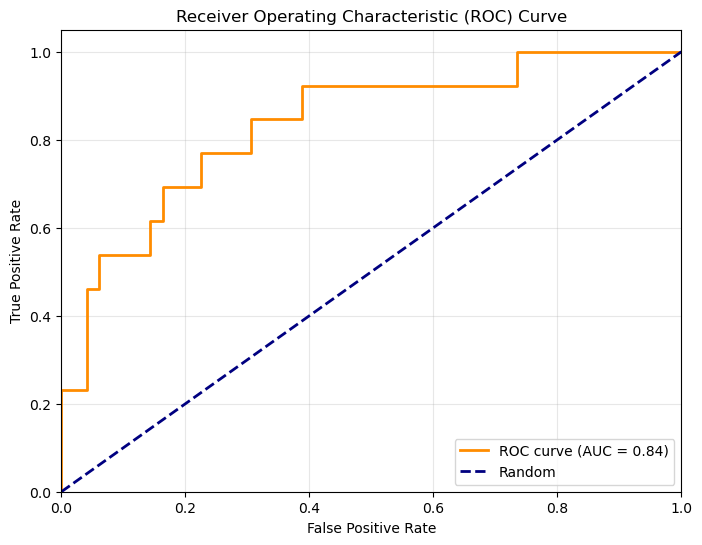

In [194]:
# T17: Plot ROC curve
from sklearn.metrics import roc_curve, auc

# Filter for valid binary labels (0 or 1) and remove NaN values
valid_indices = ~np.isnan(y_test) & ((y_test == 0) | (y_test == 1))
y_test_clean = y_test[valid_indices].astype(int)
x_test_clean = x_test[valid_indices]

print(f"Using {len(y_test_clean)} samples out of {len(y_test)} total")
print(f"Unique values after filtering: {np.unique(y_test_clean)}")

# Get prediction scores
scores = model.predict_proba_scores(x_test_clean, use_gaussian=False)

# Calculate ROC curve
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_clean, scores)
roc_auc = auc(fpr_roc, tpr_roc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### T18. Change the number of discretization bins to 5. What happens to the RoC curve? Which discretization is better? The number of discretization bins can be considered as a hyperparameter, and must be chosen by comparing the final performance.


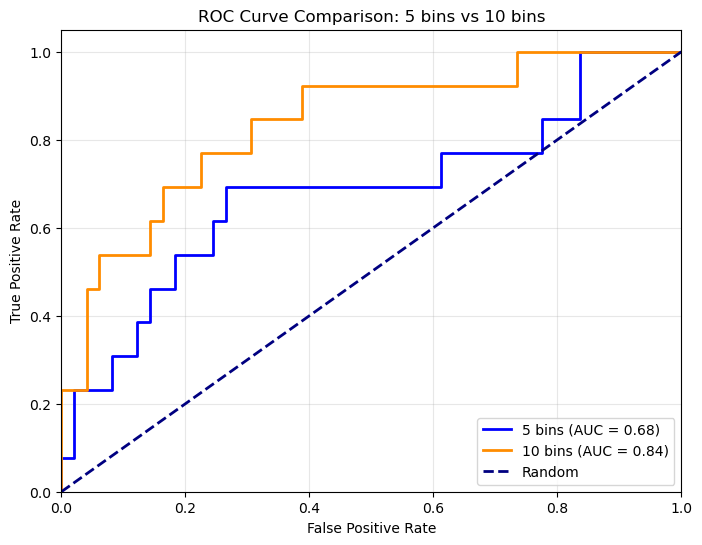


5 bins AUC: 0.6813
10 bins AUC: 0.8352

The discretization with 10 bins performs better based on AUC.


In [195]:
# T18: Compare with 5 bins
model_5bins = SimpleBayesClassifier(n_pos=int(np.sum(y_train == 1)), n_neg=int(np.sum(y_train == 0)))
model_5bins.n_bins = 5
model_5bins.fit_params(x_train, y_train)

# Filter for valid binary labels (0 or 1) and remove NaN values
valid_indices = ~np.isnan(y_test) & ((y_test == 0) | (y_test == 1))
y_test_clean = y_test[valid_indices].astype(int)
x_test_clean = x_test[valid_indices]

# Get scores for 5 bins model
scores_5bins = model_5bins.predict_proba_scores(x_test_clean, use_gaussian=False)
fpr_5bins, tpr_5bins, _ = roc_curve(y_test_clean, scores_5bins)
roc_auc_5bins = auc(fpr_5bins, tpr_5bins)

# Get scores for 10 bins model
scores_10bins = model.predict_proba_scores(x_test_clean, use_gaussian=False)
fpr_10bins, tpr_10bins, _ = roc_curve(y_test_clean, scores_10bins)
roc_auc_10bins = auc(fpr_10bins, tpr_10bins)

# Plot comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_5bins, tpr_5bins, color='blue', lw=2, label=f'5 bins (AUC = {roc_auc_5bins:.2f})')
plt.plot(fpr_10bins, tpr_10bins, color='darkorange', lw=2, label=f'10 bins (AUC = {roc_auc_10bins:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: 5 bins vs 10 bins')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n5 bins AUC: {roc_auc_5bins:.4f}")
print(f"10 bins AUC: {roc_auc_10bins:.4f}")
print(f"\nThe discretization with {'5' if roc_auc_5bins > roc_auc_10bins else '10'} bins performs better based on AUC.")